# Wild-Tool-Bench — Strategy Analysis (120B vs. Laguna)

Analysis of the tool-selection-strategy runs for two executing models — `openai/gpt-oss-120b` ("120B")
and "Laguna" — across:

`in_context`, `embedding`, `embedding_context`, `reranker`, `reranker_context`, `hierarchical`

Data sources used (per model):
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_metric.json` / `score/laguna_<strategy>/langgraph/Wild-Tool-Bench_metric.json` — official aggregated accuracy/optimality/progress metrics.
- `score/120B_<strategy>/langgraph/Wild-Tool-Bench_score.jsonl` / `score/laguna_<strategy>/langgraph/Wild-Tool-Bench_score.jsonl` — per-task correctness (`label`), optimality, predicted tool calls and final answers.
- `result_v3_120B/<strategy>/langgraph/Wild-Tool-Bench_metrics_summary.jsonl` / `result_laguna/<strategy>/langgraph/Wild-Tool-Bench_metrics_summary.jsonl` — per-task token counts and latency.
- `result_v3_120B/<strategy>/tool_selection_logs.jsonl` / `result_laguna/<strategy>/tool_selection_logs.jsonl` — candidate tools handed to the LLM by the selection strategy (absent for `in_context`).
- `result_v3_120B/<strategy>/tool_call_logs.jsonl` / `result_laguna/<strategy>/tool_call_logs.jsonl` — tool calls actually issued by the executing LLM.
- `data/Wild-Tool-Bench.jsonl` — benchmark definition incl. gold trajectories (`english_answer_list`), task types and turn subtypes (shared across models).

Sections:
1. Setup & data loading
2. Official WTB metrics (task/session accuracy, task type, layer, turn subtype, optimality, progress)
3. Token count & latency comparison
4. Token count vs. accuracy
5. Inter-strategy comparison: unique wins
6. Gold-tool coverage of the tool selection stage
7. Rank position of the executing LLM's tool calls
8. Single-task deep dive: gold trajectory vs. selected/executed tools & answer
9. Model comparison: 120B vs. Laguna


In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "wild-tool-bench":
    ROOT = ROOT / "wild-tool-bench"

STRATEGIES = ["in_context", "embedding", "embedding_context", "reranker", "reranker_context", "hierarchical"]
STRATEGY_LABELS = {
    "in_context": "In-Context",
    "embedding": "Embedding",
    "embedding_context": "Embedding+Context",
    "reranker": "Reranker",
    "reranker_context": "Reranker+Context",
    "hierarchical": "Hierarchical",
}
COLORS = dict(zip(STRATEGIES, plt.cm.tab10.colors))

MODELS = ["120B", "Laguna"]
MODEL_LABELS = {"120B": "GPT-OSS-120B", "Laguna": "Laguna"}

# Per-model score directory names and result roots. `laguna_in__context` uses a
# double underscore in its score dir name, unlike every other laguna strategy.
SCORE_DIRS = {
    "120B": {s: f"120B_{s}" for s in STRATEGIES},
    "Laguna": {**{s: f"laguna_{s}" for s in STRATEGIES}, "in_context": "laguna_in__context"},
}
RESULT_ROOTS = {"120B": "result_v3_120B", "Laguna": "result_laguna"}

DATA_FILE = ROOT / "data/Wild-Tool-Bench.jsonl"
SCORE_ROOT = ROOT / "score"


def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Setup & data loading

Builds a gold-task index (task type, turn subtype, layer, gold tool trajectory) from the benchmark
definition, then loads the per-task score/metrics/selection/tool-call logs for every strategy.


In [2]:
benchmark = read_jsonl(DATA_FILE)


def build_gold_index(rows: list[dict]) -> dict[tuple[str, int], dict]:
    """One entry per (session id, task_idx) with gold task metadata and the gold tool trajectory."""
    idx = {}
    for rec in rows:
        eid = rec["id"]
        n = len(rec["english_tasks"])
        for i in range(n):
            gold_actions = rec["english_answer_list"][i] if i < len(rec["english_answer_list"]) else []
            gold_tools = [
                a.get("action", {}).get("name")
                for a in gold_actions
                if a.get("action", {}).get("name") and a["action"]["name"] != "prepare_to_answer"
            ]
            idx[(eid, i)] = {
                "task_type": rec["english_task_types"][i],
                "turn_type": "First Turn" if not rec["turn_types"][i] else "Subsequent Turn",
                "turn_subtype": rec["english_turn_subtypes"][i - 1] if i > 0 else None,
                "layer": i,
                "query": rec["english_tasks"][i],
                "gold_tools": gold_tools,
                "gold_tools_unique": sorted(set(gold_tools)),
                "gold_actions": gold_actions,
            }
    return idx


gold_index = build_gold_index(benchmark)
print(f"{len(gold_index)} gold tasks across {len(benchmark)} sessions")


1024 gold tasks across 256 sessions


In [21]:
def extract_step_info(inference_log: dict) -> tuple[list[str], str | None]:
    """Returns (predicted tool names in call order, final answer text) for one task's inference log."""
    step_keys = sorted(
        (k for k in inference_log if str(k).startswith("step_")),
        key=lambda x: int(x.split("_")[1]),
    )
    predicted_tools, final_answer = [], None
    for sk in step_keys:
        out = inference_log[sk].get("inference_output", {}) or {}
        for tc in out.get("tool_calls", []) or []:
            fn = tc.get("function", {}) or {}
            if fn.get("name"):
                predicted_tools.append(fn["name"])
        if out.get("content"):
            final_answer = out["content"]
    return predicted_tools, final_answer


def load_strategy_tasks(model: str, strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task correctness/optimality/predicted tools/final answer from Wild-Tool-Bench_score.jsonl."""
    score_rows = read_jsonl(SCORE_ROOT / SCORE_DIRS[model][strategy] / "langgraph/Wild-Tool-Bench_score.jsonl")
    tasks = {}
    for rec in score_rows:
        eid = rec["id"]
        for i, item in enumerate(rec["results"]):
            log = item.get("inference_log", {}) or {}
            predicted_tools, final_answer = extract_step_info(log) if log else ([], None)
            tasks[(eid, i)] = {
                "correct": item.get("label") == "correct",
                "optimal": bool(item.get("is_optimal", False)),
                "predicted_tools": predicted_tools,
                "final_answer": final_answer,
            }
    return tasks


def load_strategy_token_metrics(model: str, strategy: str) -> dict[tuple[str, int], dict]:
    """Per-task token/latency figures from Wild-Tool-Bench_metrics_summary.jsonl."""
    rows = read_jsonl(ROOT / RESULT_ROOTS[model] / strategy / "langgraph/Wild-Tool-Bench_metrics_summary.jsonl")
    out = {}
    for rec in rows:
        eid = rec["id"]
        for pt in rec["metrics"].get("per_task", []):
            out[(eid, pt["task_idx"])] = {
                "input_tokens": pt.get("input_tokens", 0) or 0,
                "output_tokens": pt.get("output_tokens", 0) or 0,
                "total_tokens": pt.get("total_tokens", 0) or 0,
                "llm_latency_s": pt.get("llm_latency_s", 0) or 0,
                "embedding_total_tokens": pt.get("embedding_total_tokens", 0) or 0,
                "reranker_total_tokens": pt.get("reranker_total_tokens", 0) or 0,
                "selector_total_tokens": pt.get("selector_total_tokens", 0) or 0,
            }
    return out


def load_strategy_selection(model: str, strategy: str) -> dict[tuple[str, int], set[str]]:
    """Union of tool names ever offered to the LLM by the selection stage, per task."""
    path = ROOT / RESULT_ROOTS[model] / strategy / "tool_selection_logs.jsonl"
    out = defaultdict(set)
    if not path.exists():
        return out
    for row in read_jsonl(path):
        out[(row["test_entry_id"], row["task_idx"])].update(row.get("selected_tool_names", []))
    return out


def load_strategy_selection_ranked(model: str, strategy: str) -> dict[tuple[str, int], list[str]]:
    """Rank-ordered tool names from the selection stage's first call, per task (index 0 = top-ranked)."""
    path = ROOT / RESULT_ROOTS[model] / strategy / "tool_selection_logs.jsonl"
    out = {}
    if not path.exists():
        return out
    rows = read_jsonl(path)
    rows.sort(key=lambda r: r.get("timestamp", 0))
    for row in rows:
        key = (row["test_entry_id"], row["task_idx"])
        if key not in out:
            out[key] = row.get("selected_tool_names", [])
    return out


def load_strategy_tool_calls(model: str, strategy: str) -> dict[tuple[str, int], list[dict]]:
    """Actual tool calls issued by the executing LLM, per task, in chronological order."""
    rows = read_jsonl(ROOT / RESULT_ROOTS[model] / strategy / "tool_call_logs.jsonl")
    rows.sort(key=lambda r: r.get("timestamp", 0))
    out = defaultdict(list)
    for row in rows:
        key = (row["test_entry_id"], row["task_idx"])
        for tc in row.get("returned_tool_calls", []) or []:
            out[key].append({"name": tc.get("name"), "arguments": tc.get("arguments")})
    return out


all_data = {}
for m in MODELS:
    all_data[m] = {}
    for s in STRATEGIES:
        all_data[m][s] = {
            "tasks": load_strategy_tasks(m, s),
            "tokens": load_strategy_token_metrics(m, s),
            "selection": load_strategy_selection(m, s),
            "selection_ranked": load_strategy_selection_ranked(m, s),
            "tool_calls": load_strategy_tool_calls(m, s),
            "metric": json.load(open(SCORE_ROOT / SCORE_DIRS[m][s] / "langgraph/Wild-Tool-Bench_metric.json")),
        }
        n_tasks = len(all_data[m][s]["tasks"])
        n_correct = sum(t["correct"] for t in all_data[m][s]["tasks"].values())
        print(f"{m:8s} {s:20s} tasks={n_tasks:4d}  correct={n_correct:4d}  acc={n_correct / n_tasks:.4f}")


120B     in_context           tasks=1024  correct= 371  acc=0.3623
120B     embedding            tasks=1024  correct= 327  acc=0.3193
120B     embedding_context    tasks=1024  correct= 367  acc=0.3584
120B     reranker             tasks=1024  correct= 314  acc=0.3066
120B     reranker_context     tasks=1024  correct= 360  acc=0.3516
120B     hierarchical         tasks=1024  correct= 373  acc=0.3643
Laguna   in_context           tasks=1024  correct= 411  acc=0.4014
Laguna   embedding            tasks=1024  correct= 353  acc=0.3447
Laguna   embedding_context    tasks=1024  correct= 394  acc=0.3848
Laguna   reranker             tasks=1024  correct= 360  acc=0.3516
Laguna   reranker_context     tasks=1024  correct= 401  acc=0.3916
Laguna   hierarchical         tasks=1024  correct= 420  acc=0.4102


In [22]:
rows = []
for m in MODELS:
    for s in STRATEGIES:
        tasks = all_data[m][s]["tasks"]
        tokens = all_data[m][s]["tokens"]
        for key, gold in gold_index.items():
            task = tasks.get(key, {"correct": False, "optimal": False, "predicted_tools": [], "final_answer": None})
            tok = tokens.get(key, {})
            rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "task_type": gold["task_type"],
                "turn_type": gold["turn_type"],
                "turn_subtype": gold["turn_subtype"],
                "layer": gold["layer"],
                "correct": task["correct"],
                "optimal": task["optimal"],
                "total_tokens": tok.get("total_tokens", 0),
                "input_tokens": tok.get("input_tokens", 0),
                "output_tokens": tok.get("output_tokens", 0),
                "llm_latency_s": tok.get("llm_latency_s", 0),
                "pipeline_tokens": tok.get("total_tokens", 0) + tok.get("embedding_total_tokens", 0)
                    + tok.get("reranker_total_tokens", 0) + tok.get("selector_total_tokens", 0),
            })
task_df = pd.DataFrame(rows)
task_df.head()


,model,strategy,task_id,task_idx,task_type,turn_type,turn_subtype,layer,correct,optimal,total_tokens,input_tokens,output_tokens,llm_latency_s,pipeline_tokens
0,120B,in_context,wild_tool_bench_0,0,Single-Tool,First Turn,NaN,0,True,True,116631,116330,301,14.888,116631
1,120B,in_context,wild_tool_bench_0,1,Single-Tool,Subsequent Turn,Partial Information,1,True,True,117053,116874,179,7.025,117053
2,120B,in_context,wild_tool_bench_0,2,Mixed Multi-Tool,Subsequent Turn,Partial Information,2,False,False,58818,58608,210,8.077,58818
3,120B,in_context,wild_tool_bench_0,3,Chat,Subsequent Turn,Coreferential Reference,3,True,True,59496,59251,245,9.354,59496
4,120B,in_context,wild_tool_bench_1,0,Single-Tool,First Turn,NaN,0,False,False,116400,116045,355,16.646,116400


## 2. Official WTB metrics

Directly visualizes the numbers already computed in each strategy's `Wild-Tool-Bench_metric.json`:
task/session accuracy, task-type accuracy, layer (turn position) accuracy, turn-subtype accuracy,
optimality score and progress info.


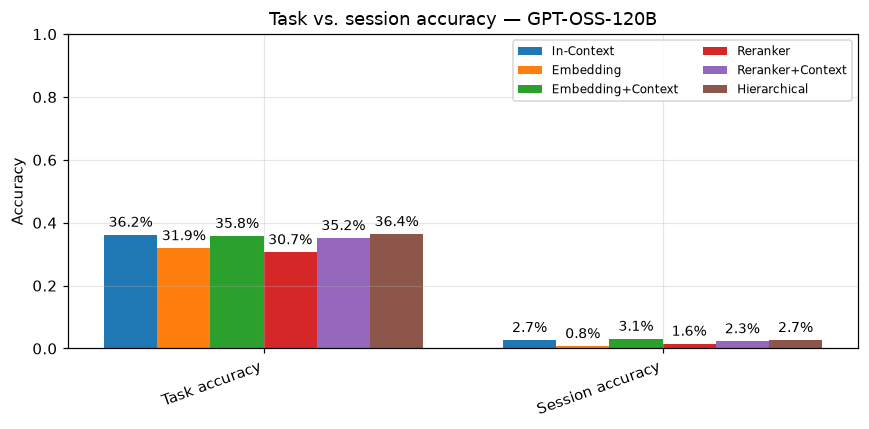

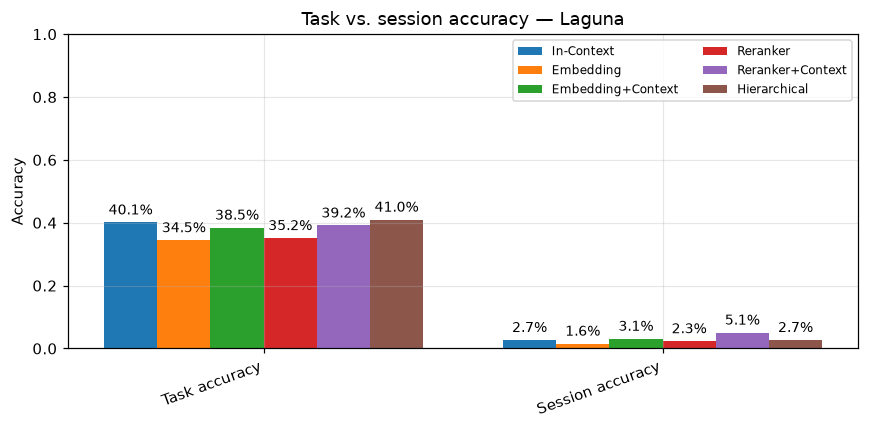

In [23]:
def grouped_bar(ax, categories: list[str], series: dict[str, list[float]], ylabel: str, title: str, pct: bool = True):
    n_groups, n_series = len(categories), len(series)
    width = 0.8 / n_series
    x = range(n_groups)

    for i, (s, values) in enumerate(series.items()):
        offsets = [xi + i * width - 0.4 + width / 2 for xi in x]

        bars = ax.bar(
            offsets,
            values,
            width=width,
            label=STRATEGY_LABELS[s],
            color=COLORS[s]
        )

        # Add value labels above each bar
        labels = [f"{v:.1%}" if pct else f"{v:.3f}" for v in values]
        ax.bar_label(
            bars,
            labels=labels,
            padding=3,
            fontsize=9
        )

    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if pct:
        ax.set_ylim(
            0,
            max(1.0, max(v for vals in series.values() for v in vals) * 1.15)
        )

    ax.legend(fontsize=8, ncol=2)


# Task & session accuracy, per model
for m in MODELS:
    categories = ["Task accuracy", "Session accuracy"]

    series = {
        s: [
            all_data[m][s]["metric"]["total_info"]["task"]["accuracy"],
            all_data[m][s]["metric"]["total_info"]["session"]["accuracy"]
        ]
        for s in STRATEGIES
    }

    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(
        ax,
        categories,
        series,
        "Accuracy",
        f"Task vs. session accuracy — {MODEL_LABELS[m]}"
    )

    plt.tight_layout()
    plt.show()


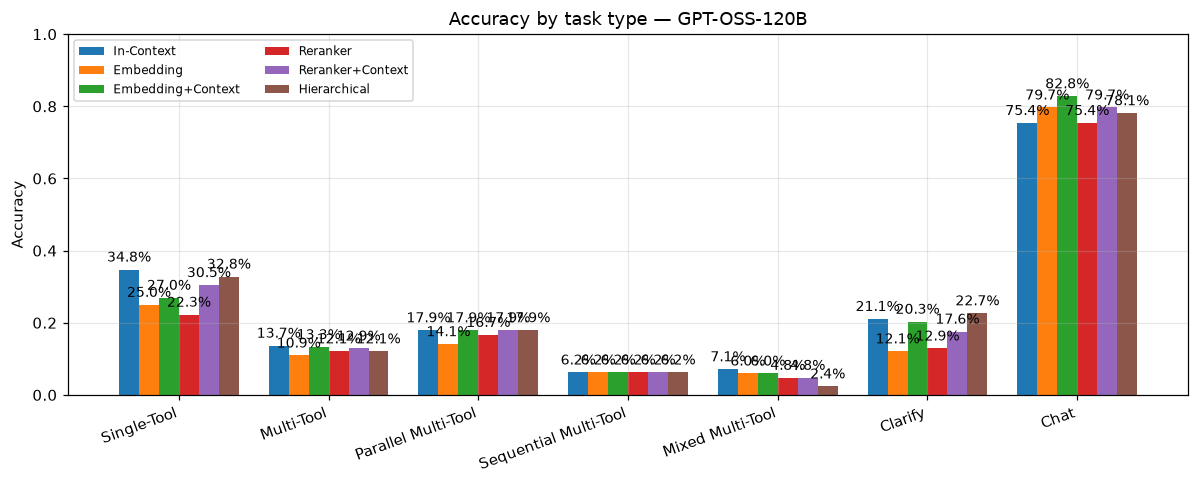

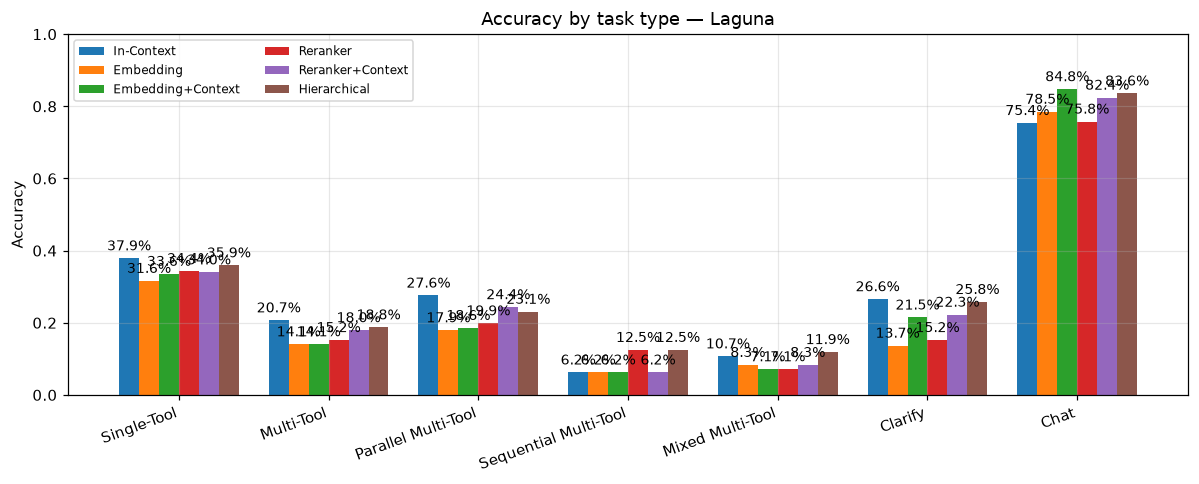

In [24]:
# Task-type accuracy, per model
task_types = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["task_type_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["task_type_info"][t]["accuracy"] for t in task_types] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(11, 4.5))
    grouped_bar(ax, task_types, series, "Accuracy", f"Accuracy by task type — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


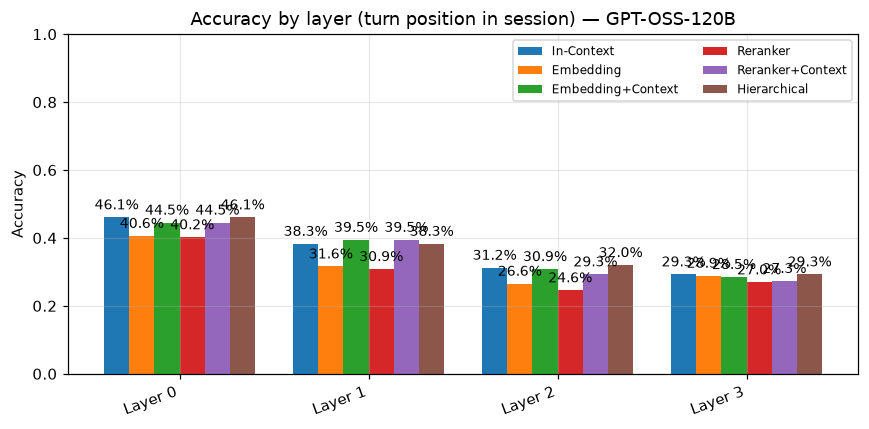

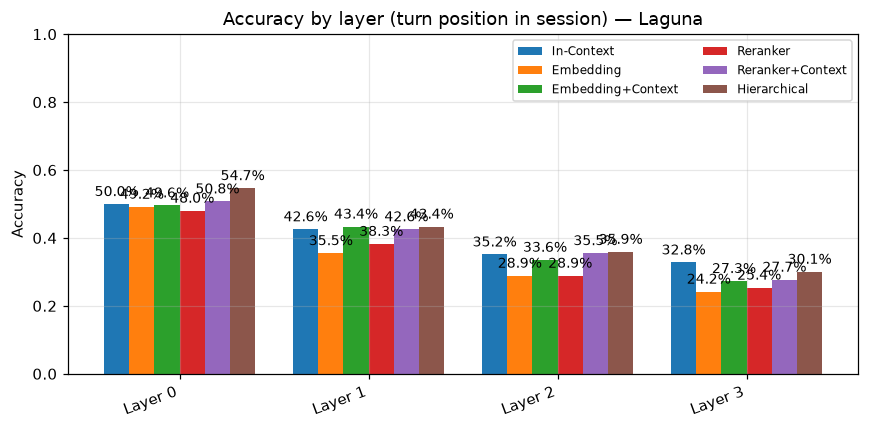

In [25]:
# Layer (turn position) accuracy, per model
layers = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["layer_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["layer_info"][l]["accuracy"] for l in layers] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, [f"Layer {l}" for l in layers], series, "Accuracy", f"Accuracy by layer (turn position in session) — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


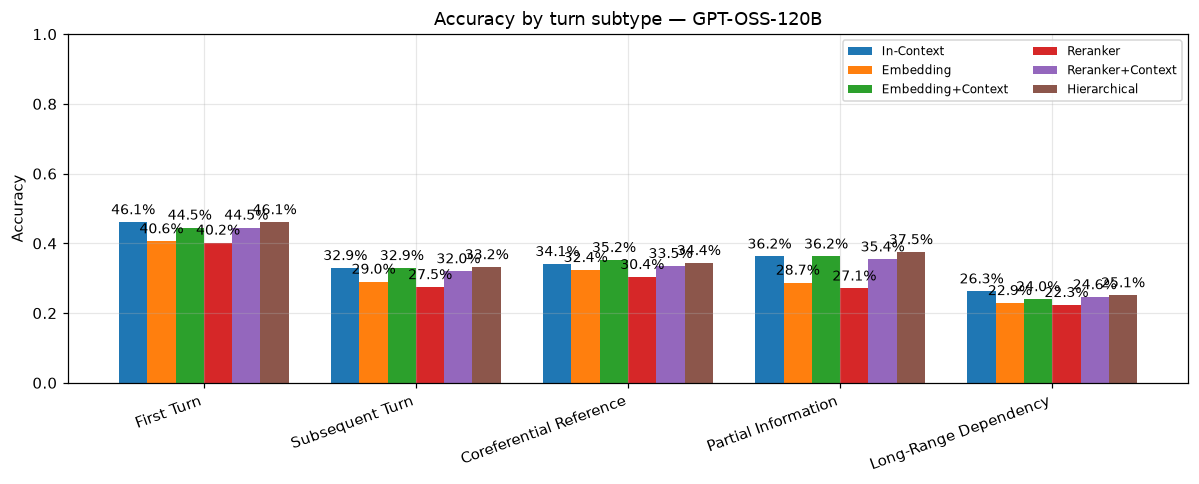

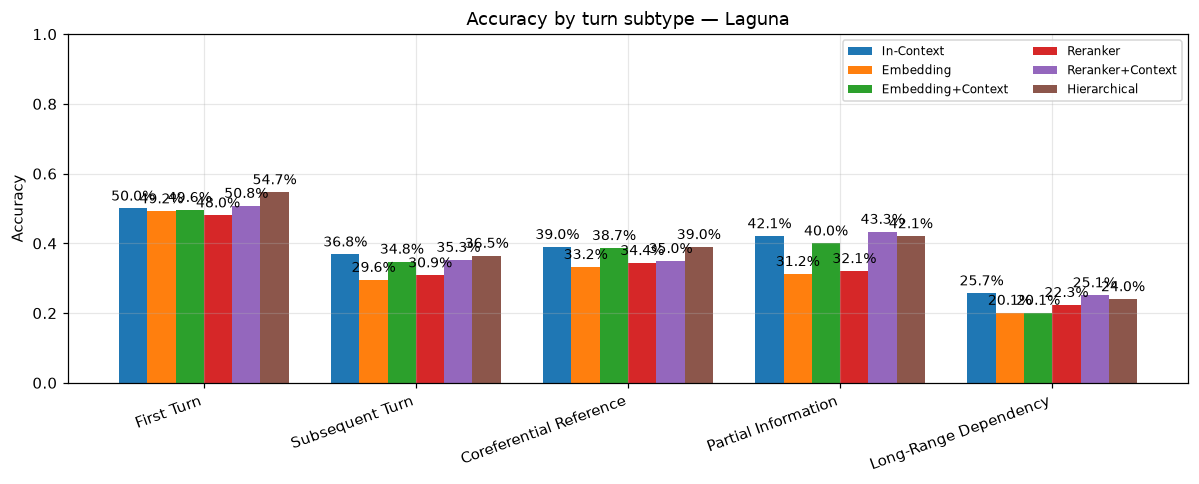

In [26]:
# Turn-subtype accuracy, per model
subtypes = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["turn_subtype_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["turn_subtype_info"][t]["accuracy"] for t in subtypes] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(11, 4.5))
    grouped_bar(ax, subtypes, series, "Accuracy", f"Accuracy by turn subtype — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


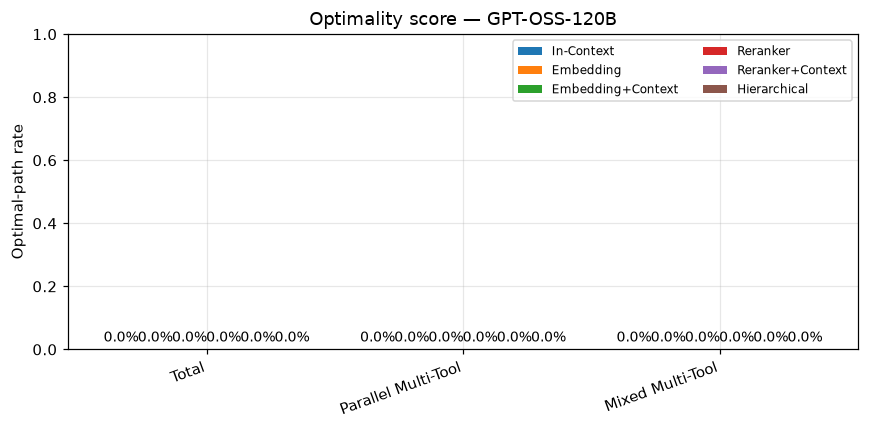

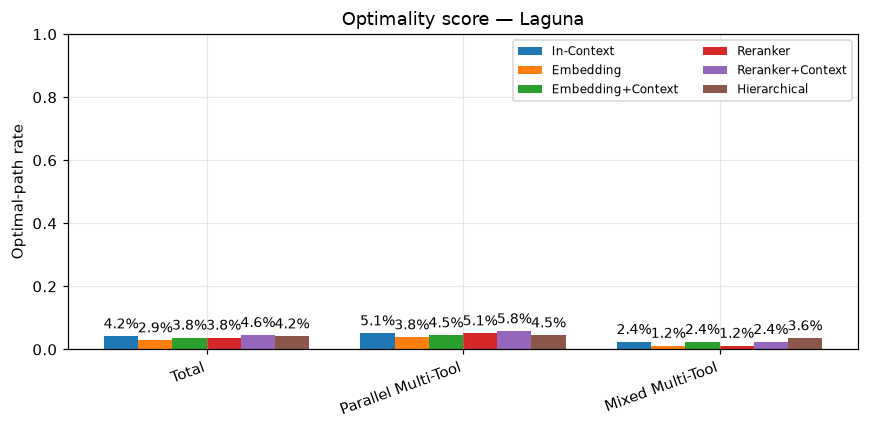

In [27]:
# Optimality score (only defined for Parallel/Mixed Multi-Tool, where multiple valid orderings exist), per model
optimal_keys = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["optimal_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["optimal_info"][k]["accuracy"] for k in optimal_keys] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, optimal_keys, series, "Optimal-path rate", f"Optimality score — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


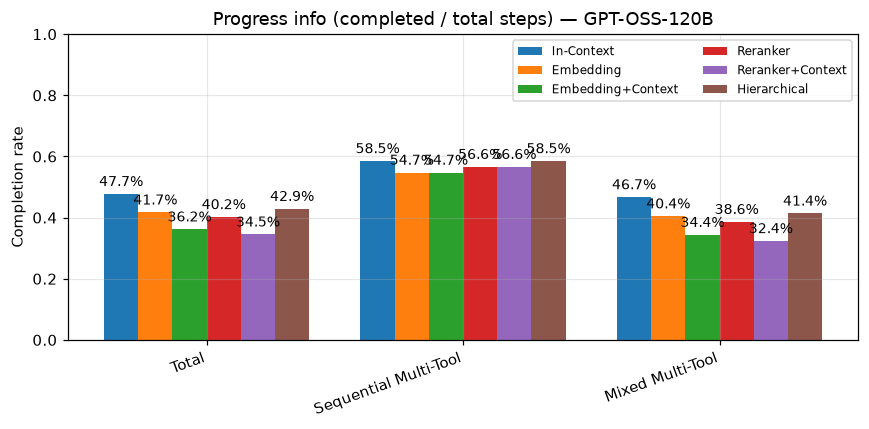

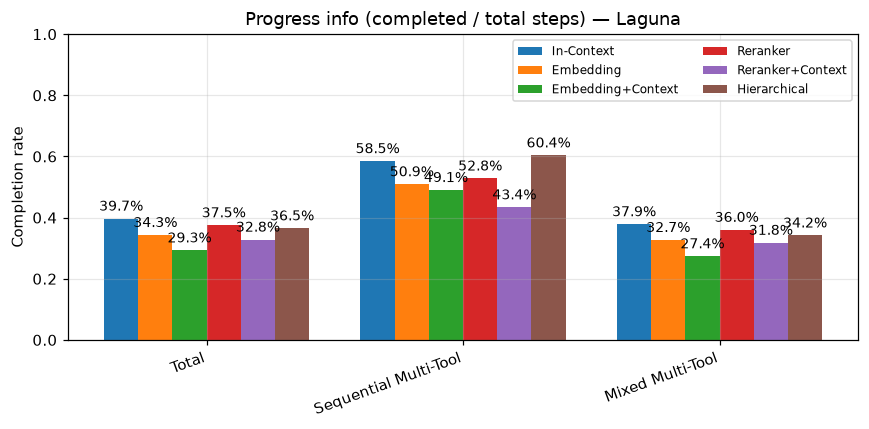

In [28]:
# Progress info: share of completed steps in multi-step tasks (Sequential/Mixed Multi-Tool), per model
progress_keys = list(all_data[MODELS[0]][STRATEGIES[0]]["metric"]["progress_info"].keys())
for m in MODELS:
    series = {s: [all_data[m][s]["metric"]["progress_info"][k]["rate"] for k in progress_keys] for s in STRATEGIES}
    fig, ax = plt.subplots(figsize=(8, 4))
    grouped_bar(ax, progress_keys, series, "Completion rate", f"Progress info (completed / total steps) — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


## 3. Token count & latency comparison

`total_tokens` / `llm_latency_s` are the executing LLM's own usage. `pipeline_tokens` additionally
includes the embedding/reranker/selector overhead spent on tool selection (0 for `in_context`, which
puts all tools directly in context).


In [29]:
token_summary = task_df.groupby(["model", "strategy"]).agg(
    total_llm_tokens=("total_tokens", "sum"),
    total_pipeline_tokens=("pipeline_tokens", "sum"),
    avg_llm_tokens=("total_tokens", "mean"),
    avg_pipeline_tokens=("pipeline_tokens", "mean"),
    avg_output_tokens=("output_tokens", "mean"),
    total_latency_s=("llm_latency_s", "sum"),
    avg_latency_s=("llm_latency_s", "mean"),
).reindex(pd.MultiIndex.from_product([MODELS, STRATEGIES], names=["model", "strategy"]))
token_summary


total_llm_tokens  total_pipeline_tokens  \
model  strategy                                                     
120B   in_context                122702102              122702102   
       embedding                   3109992                3393091   
       embedding_context           3129975                4194331   
       reranker                    3154458                3550034   
       reranker_context            3168218                4252511   
       hierarchical                3386358               44625635   
Laguna in_context                248185134              248185134   
       embedding                   2862857                3140910   
       embedding_context           2808826                3803075   
       reranker                    2935722                3265764   
       reranker_context            2930489                3863921   
       hierarchical                3180148               41409882   

                          avg_llm_tokens  avg_pipeline_tokens  \
model  strategy                                                 
120B   in_context          119826.271484        119826.271484   
       embedding             3037.101562          3313.565430   
       embedding_context     3056.616211          4096.026367   
       reranker              3080.525391          3466.830078   
       reranker_context      3093.962891          4152.842773   
       hierarchical          3306.990234         43579.721680   
Laguna in_context          242368.294922        242368.294922   
       embedding             2795.758789          3067.294922   
       embedding_context     2742.994141          3713.940430   
       reranker              2866.916016          3189.222656   
       reranker_context      2861.805664          3773.360352   
       hierarchical          3105.613281         40439.337891   

                          avg_output_tokens  total_latency_s  avg_latency_s  
model  strategy                                                              
120B   in_context                685.992188        28333.943      27.669866  
       embedding                 779.319336        30766.191      30.045108  
       embedding_context         773.666992        30845.640      30.122695  
       reranker                  718.897461        29460.813      28.770325  
       reranker_context          754.249023        31758.186      31.013854  
       hierarchical              712.668945        36954.388      36.088270  
Laguna in_context                377.037109         5276.455       5.152788  
       embedding                 235.771484         2807.731       2.741925  
       embedding_context         199.988281         3107.317       3.034489  
       reranker                  208.180664         5284.329       5.160478  
       reranker_context          212.219727         5236.192       5.113469  
       hierarchical              224.532227        11363.455      11.097124

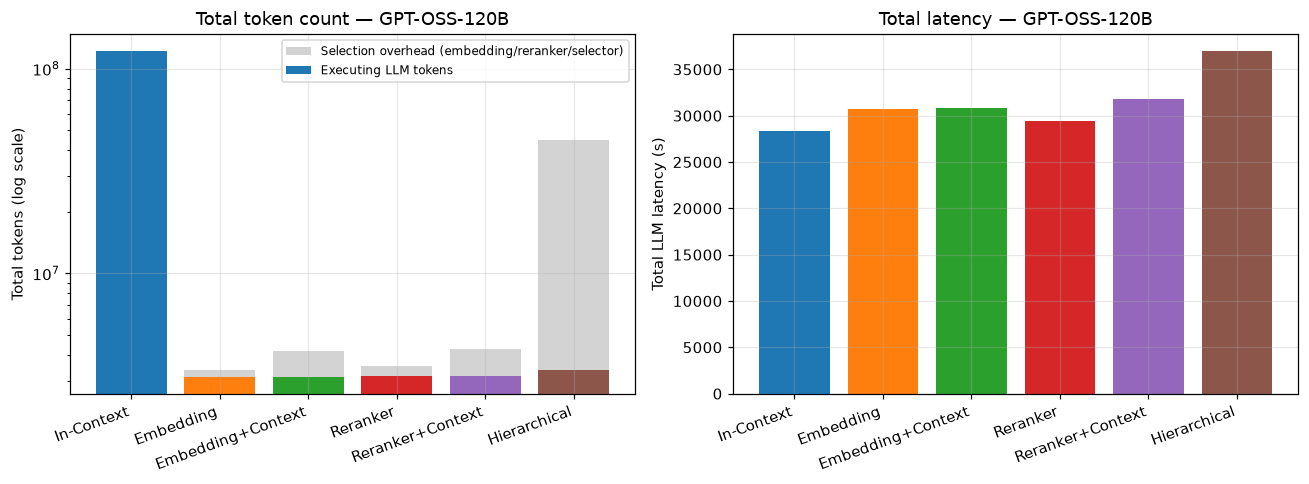

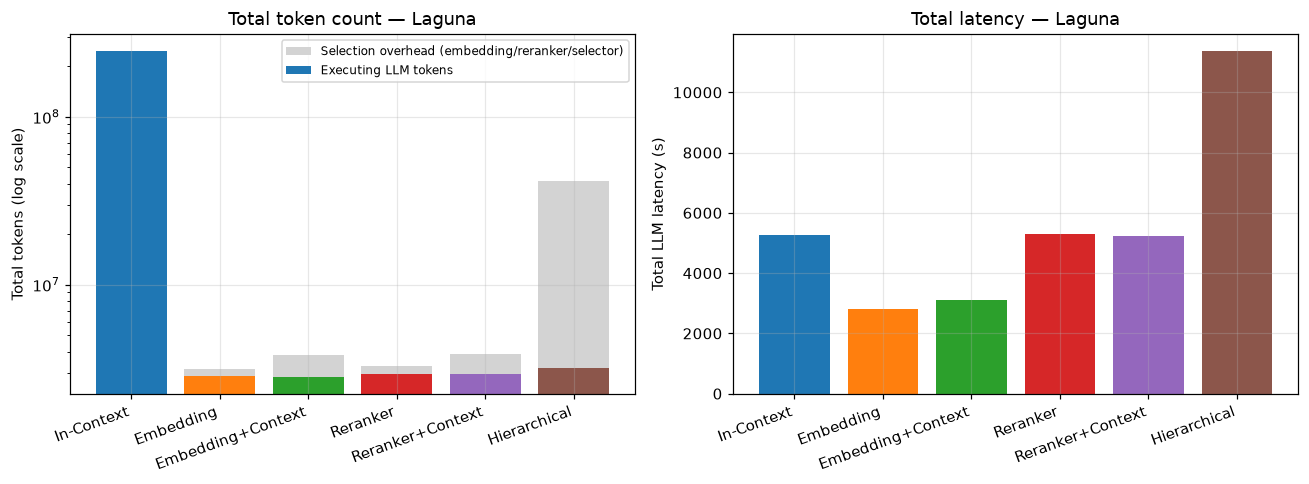

In [30]:
labels = [STRATEGY_LABELS[s] for s in STRATEGIES]
x = range(len(STRATEGIES))

for m in MODELS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    llm_totals = [token_summary.loc[(m, s), "total_llm_tokens"] for s in STRATEGIES]
    pipeline_totals = [token_summary.loc[(m, s), "total_pipeline_tokens"] for s in STRATEGIES]
    axes[0].bar(x, pipeline_totals, color="lightgray", label="Selection overhead (embedding/reranker/selector)")
    axes[0].bar(x, llm_totals, color=[COLORS[s] for s in STRATEGIES], label="Executing LLM tokens")
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels, rotation=20, ha="right")
    axes[0].set_ylabel("Total tokens (log scale)")
    axes[0].set_yscale("log")
    axes[0].set_title(f"Total token count — {MODEL_LABELS[m]}")
    axes[0].legend(fontsize=8)

    lat_totals = [token_summary.loc[(m, s), "total_latency_s"] for s in STRATEGIES]
    axes[1].bar(x, lat_totals, color=[COLORS[s] for s in STRATEGIES])
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels, rotation=20, ha="right")
    axes[1].set_ylabel("Total LLM latency (s)")
    axes[1].set_title(f"Total latency — {MODEL_LABELS[m]}")

    plt.tight_layout()
    plt.show()


## 4. Token count vs. accuracy

Average tokens spent per task against the task accuracy achieved, per strategy.


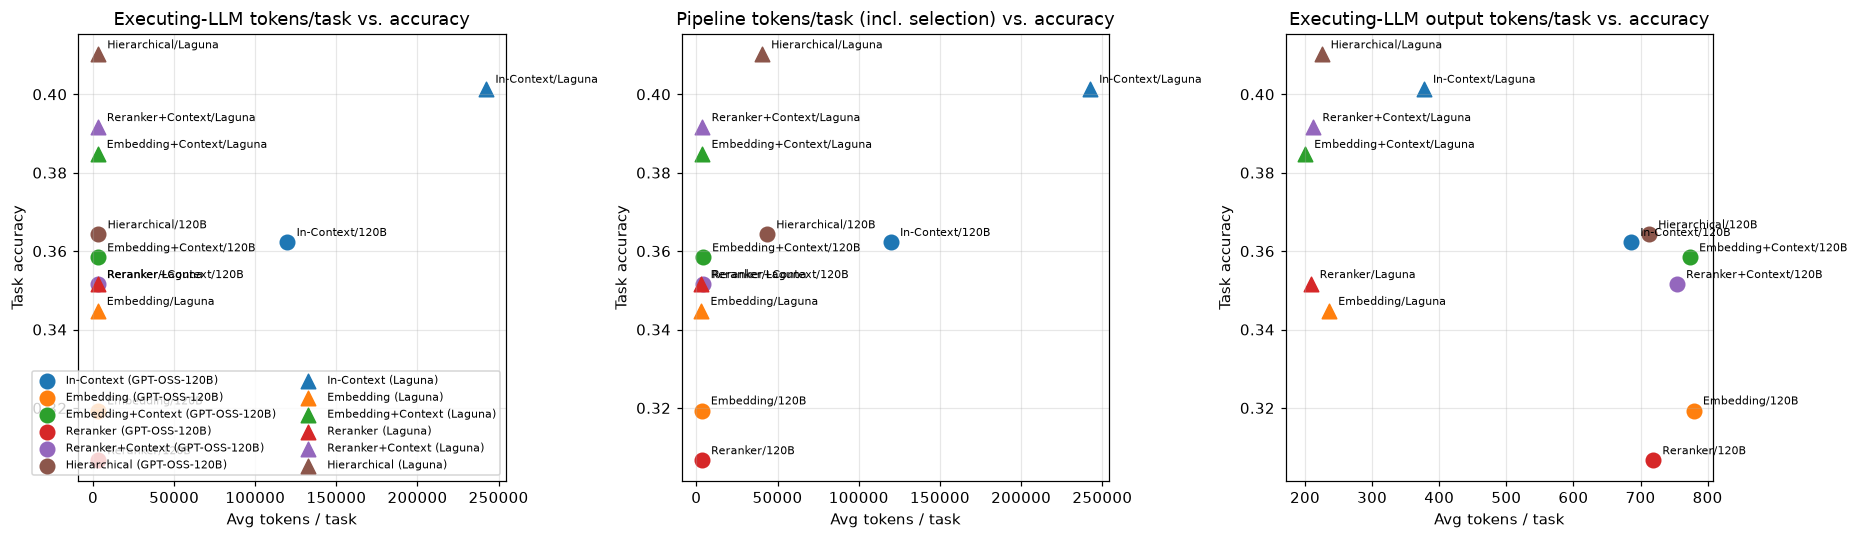

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
MODEL_MARKERS = {"120B": "o", "Laguna": "^"}

for ax, token_col, title in [
    (axes[0], "avg_llm_tokens", "Executing-LLM tokens/task vs. accuracy"),
    (axes[1], "avg_pipeline_tokens", "Pipeline tokens/task (incl. selection) vs. accuracy"),
    (axes[2], "avg_output_tokens", "Executing-LLM output tokens/task vs. accuracy"),
]:
    for m in MODELS:
        for s in STRATEGIES:
            acc = all_data[m][s]["metric"]["total_info"]["task"]["accuracy"]
            tok = token_summary.loc[(m, s), token_col]
            ax.scatter(tok, acc, s=90, color=COLORS[s], marker=MODEL_MARKERS[m],
                       label=f"{STRATEGY_LABELS[s]} ({MODEL_LABELS[m]})")
            ax.annotate(f"{STRATEGY_LABELS[s]}/{m}", (tok, acc), textcoords="offset points", xytext=(6, 4), fontsize=7)
    ax.set_xlabel("Avg tokens / task")
    ax.set_ylabel("Task accuracy")
    ax.set_title(title)

axes[0].legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout()
plt.show()


## 5. Inter-strategy comparison: unique wins

For each strategy, the number of tasks that *only that strategy* solved correctly (all other five
strategies got it wrong).


--- GPT-OSS-120B ---
In-Context           unique wins:  16   total correct: 371
Embedding            unique wins:   5   total correct: 327
Embedding+Context    unique wins:  11   total correct: 367
Reranker             unique wins:   3   total correct: 314
Reranker+Context     unique wins:   5   total correct: 360
Hierarchical         unique wins:  12   total correct: 373


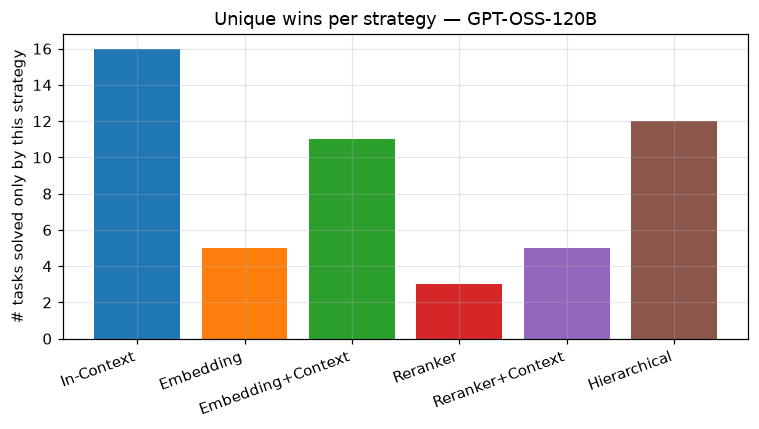

--- Laguna ---
In-Context           unique wins:  23   total correct: 411
Embedding            unique wins:   1   total correct: 353
Embedding+Context    unique wins:   7   total correct: 394
Reranker             unique wins:   2   total correct: 360
Reranker+Context     unique wins:   4   total correct: 401
Hierarchical         unique wins:   7   total correct: 420


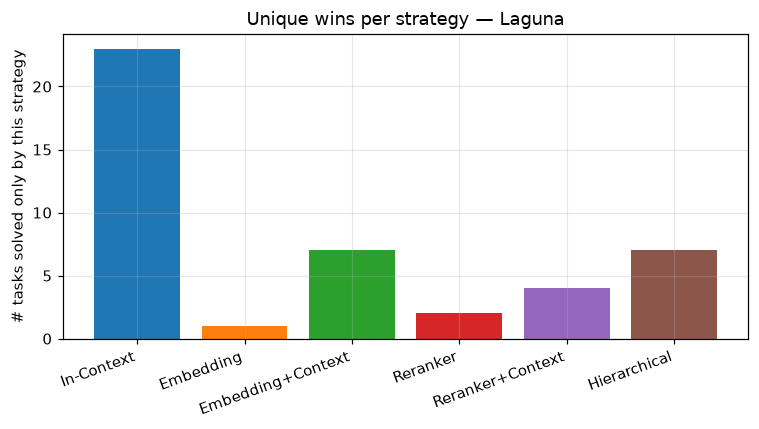

In [32]:
all_keys = set(gold_index.keys())
unique_wins_by_model = {}

for m in MODELS:
    correct_sets = {
        s: {key for key, t in all_data[m][s]["tasks"].items() if t["correct"]}
        for s in STRATEGIES
    }

    solved_by_count = Counter()
    for key in all_keys:
        for s in STRATEGIES:
            if key in correct_sets[s]:
                solved_by_count[key] += 1

    unique_wins = {}
    for s in STRATEGIES:
        unique_wins[s] = sorted(
            key for key in correct_sets[s]
            if solved_by_count[key] == 1
        )
    unique_wins_by_model[m] = unique_wins

    print(f"--- {MODEL_LABELS[m]} ---")
    for s in STRATEGIES:
        print(f"{STRATEGY_LABELS[s]:20s} unique wins: {len(unique_wins[s]):3d}   total correct: {len(correct_sets[s]):3d}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(len(STRATEGIES)), [len(unique_wins[s]) for s in STRATEGIES], color=[COLORS[s] for s in STRATEGIES])
    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], rotation=20, ha="right")
    ax.set_ylabel("# tasks solved only by this strategy")
    ax.set_title(f"Unique wins per strategy — {MODEL_LABELS[m]}")
    plt.tight_layout()
    plt.show()


## 6. Gold-tool coverage of the tool selection stage

For each task, the share of gold (ground-truth) tool names that appear anywhere in the set of tools
the selection stage handed to the LLM. `in_context` is excluded since it passes every tool through
without a selection step.


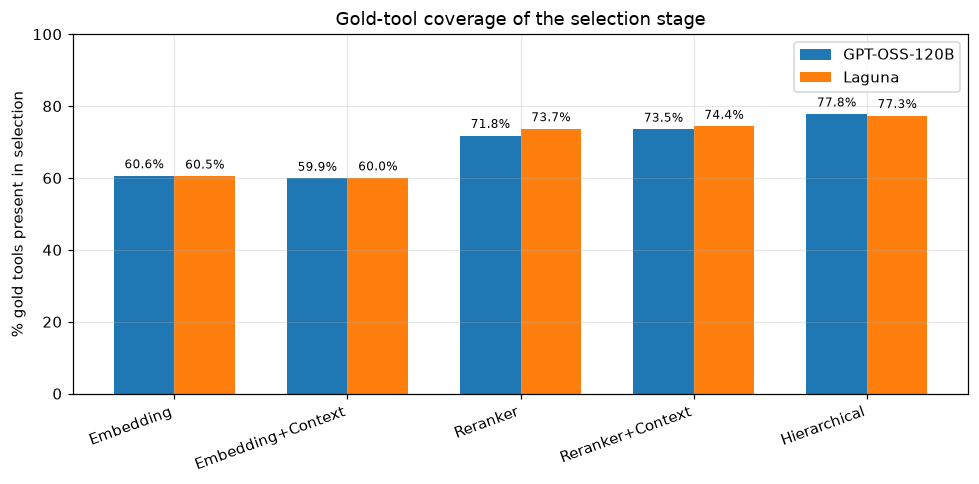

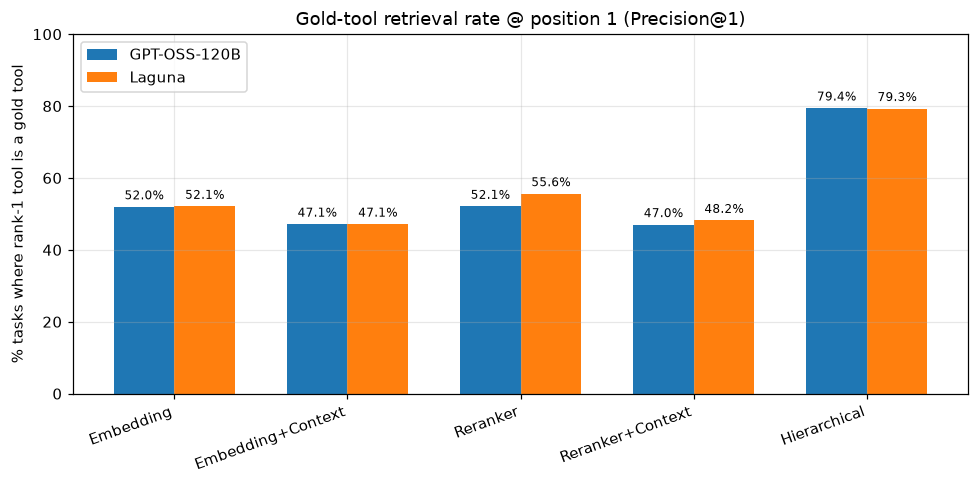

mean_gold_tool_coverage  precision_at_1
model  strategy                                                  
120B   embedding                         0.605946        0.519531
       embedding_context                 0.598720        0.471354
       hierarchical                      0.777886        0.794271
       reranker                          0.718077        0.520833
       reranker_context                  0.735373        0.470052
Laguna embedding                         0.604970        0.520833
       embedding_context                 0.600022        0.471354
       hierarchical                      0.773329        0.792969
       reranker                          0.736740        0.555990
       reranker_context                  0.743511        0.481771

In [33]:
selection_strategies = [s for s in STRATEGIES if s != "in_context"]
coverage_rows = []
for m in MODELS:
    for s in selection_strategies:
        selection = all_data[m][s]["selection"]
        selection_ranked = all_data[m][s]["selection_ranked"]
        for key, gold in gold_index.items():
            gold_tools = set(gold["gold_tools_unique"])
            if not gold_tools:
                continue  # Chat/no-tool tasks have nothing to cover
            selected = selection.get(key, set())
            top1 = next(iter(selection_ranked.get(key, [])), None)
            coverage_rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "coverage": len(gold_tools & selected) / len(gold_tools),
                "top1_hit": bool(top1 is not None and top1 in gold_tools),
            })
coverage_df = pd.DataFrame(coverage_rows)
coverage_summary = coverage_df.groupby(["model", "strategy"])["coverage"].mean()
top1_summary = coverage_df.groupby(["model", "strategy"])["top1_hit"].mean()

categories = [STRATEGY_LABELS[s] for s in selection_strategies]
series = {m: [coverage_summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}
width = 0.35
x = range(len(categories))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("% gold tools present in selection")
ax.set_title("Gold-tool coverage of the selection stage")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

# Precision@1: was the single highest-ranked tool handed to the LLM a gold tool?
series_top1 = {m: [top1_summary.loc[(m, s)] * 100 for s in selection_strategies] for m in MODELS}

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series_top1[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in series_top1[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("% tasks where rank-1 tool is a gold tool")
ax.set_title("Gold-tool retrieval rate @ position 1 (Precision@1)")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

coverage_summary.rename("mean_gold_tool_coverage").to_frame().join(
    top1_summary.rename("precision_at_1")
)


## 7. Rank position of the executing LLM's tool calls

The selection stage hands the LLM a list of candidate tools ordered by relevance (rank 1 = most
relevant). This checks whether the executing LLM actually picks the top-ranked tool for its first
call, or whether it just as often reaches for tool 2, 3, 4 or 5 — i.e. whether accuracy depends on
the gold tool being ranked first. `in_context` is excluded (no ranking is provided). Calls to a tool
name that isn't found in that task's ranked candidate list (e.g. a hallucinated name) are bucketed
as "Not in list".


In [ ]:
rank_labels = ["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5", "Rank 6+", "Not in list"]


def rank_label(pos: int | None) -> str:
    if pos is None:
        return "Not in list"
    if pos < 5:
        return rank_labels[pos]
    return "Rank 6+"


first_call_rank_rows = []
for m in MODELS:
    for s in selection_strategies:
        selection_ranked = all_data[m][s]["selection_ranked"]
        tool_calls = all_data[m][s]["tool_calls"]
        for key in gold_index:
            calls = tool_calls.get(key)
            if not calls:
                continue  # No tool call issued (e.g. chat-only turn or immediate final answer)
            ranked = selection_ranked.get(key, [])
            first_call_name = calls[0]["name"]
            pos = ranked.index(first_call_name) if first_call_name in ranked else None
            first_call_rank_rows.append({
                "model": m,
                "strategy": s,
                "task_id": key[0],
                "task_idx": key[1],
                "rank": rank_label(pos),
            })
first_call_rank_df = pd.DataFrame(first_call_rank_rows)

for m in MODELS:
    counts = (
        first_call_rank_df[first_call_rank_df["model"] == m]
        .groupby(["strategy", "rank"]).size()
        .unstack("rank")
        .reindex(index=selection_strategies, columns=rank_labels, fill_value=0)
    )
    shares = counts.div(counts.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bottom = [0.0] * len(selection_strategies)
    for rank in rank_labels:
        values = shares[rank].tolist()
        bars = ax.bar(range(len(selection_strategies)), values, bottom=bottom, label=rank)
        labels = [f"{v:.0f}%" if v >= 5 else "" for v in values]
        ax.bar_label(bars, labels=labels, label_type="center", fontsize=7, color="white")
        bottom = [b + v for b, v in zip(bottom, values)]
    ax.set_xticks(range(len(selection_strategies)))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in selection_strategies], rotation=20, ha="right")
    ax.set_ylabel("% of tasks (first tool call)")
    ax.set_ylim(0, 100)
    ax.set_title(f"Rank position of the LLM's first tool call — {MODEL_LABELS[m]}")
    ax.legend(fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.25))
    plt.tight_layout()
    plt.show()

first_call_rank_df.groupby(["model", "strategy"])["rank"].value_counts(normalize=True).mul(100).round(1).rename("pct").to_frame()


## 8. Single-task deep dive

Compare, for one task, the gold trajectory against what each strategy actually selected, called and
answered. Change `TASK_ID` / `TASK_IDX` below to inspect a different task; use the `unique_wins` /
`coverage_df` tables above to find interesting candidates (e.g. `sorted(unique_wins["hierarchical"])`).


In [34]:
def show_task_comparison(model: str, task_id: str, task_idx: int, strategies: list[str] = STRATEGIES):
    key = (task_id, task_idx)
    gold = gold_index.get(key)
    if gold is None:
        print(f"No such task: {key}")
        return

    print(f"### [{MODEL_LABELS[model]}] {task_id}[{task_idx}]  ·  {gold['task_type']}  ·  {gold['turn_type']}"
          + (f" / {gold['turn_subtype']}" if gold["turn_subtype"] else ""))
    print(f"Query: {gold['query']}\n")

    print("--- Gold trajectory ---")
    for a in gold["gold_actions"]:
        name = a.get("action", {}).get("name")
        args = a.get("action", {}).get("arguments")
        if name == "prepare_to_answer":
            print(f"  => final answer: {a.get('observation')}")
        else:
            print(f"  call {name}({args})")
    print()

    for s in strategies:
        task = all_data[model][s]["tasks"].get(key, {})
        selected = sorted(all_data[model][s]["selection"].get(key, set()))
        executed = all_data[model][s]["tool_calls"].get(key, [])
        print(f"--- {STRATEGY_LABELS[s]} ({'CORRECT' if task.get('correct') else 'INCORRECT'}"
              f"{', optimal' if task.get('optimal') else ''}) ---")
        if selected:
            print(f"  selected tools : {selected}")
        for call in executed:
            print(f"  called         : {call['name']}({call['arguments']})")
        if task.get("final_answer"):
            print(f"  final answer   : {task['final_answer']}")
        print()


# Example: first task of the first benchmark session, for the 120B model
show_task_comparison("120B", "wild_tool_bench_7", 0)


### [GPT-OSS-120B] wild_tool_bench_7[0]  ·  Single-Tool  ·  First Turn
Query: Could you please provide some detailed information about Ontario, Canada? Such as its population, area, economic situation, etc.

--- Gold trajectory ---
  call getDivisionDetails({'countryCode': 'CA', 'divisionCode': 'ON'})
  => final answer: Here is detailed information about Ontario, Canada:

- **Name**: Ontario
- **Country Code**: CA
- **Administrative Division Code**: ON
- **Type**: Province
- **Population**: 14,734,014
- **Area**: 1,076,395 square kilometers
- **GDP**: $857 billion
- **Capital**: Toronto
- **Largest City**: Toronto
- **Official Language**: English
- **Description**: Ontario is the most populous province in Canada and the second-largest in area. Its capital and largest city is Toronto. Ontario has a highly developed economy, with its GDP ranking among the top in Canadian provinces.

I hope this information is helpful to you! If you have any other questions, please feel free to let me kno

## 9. Model comparison: 120B vs. Laguna

Directly compares the two executing models against each other, for every strategy:
overall task accuracy, session accuracy and average tokens/task.


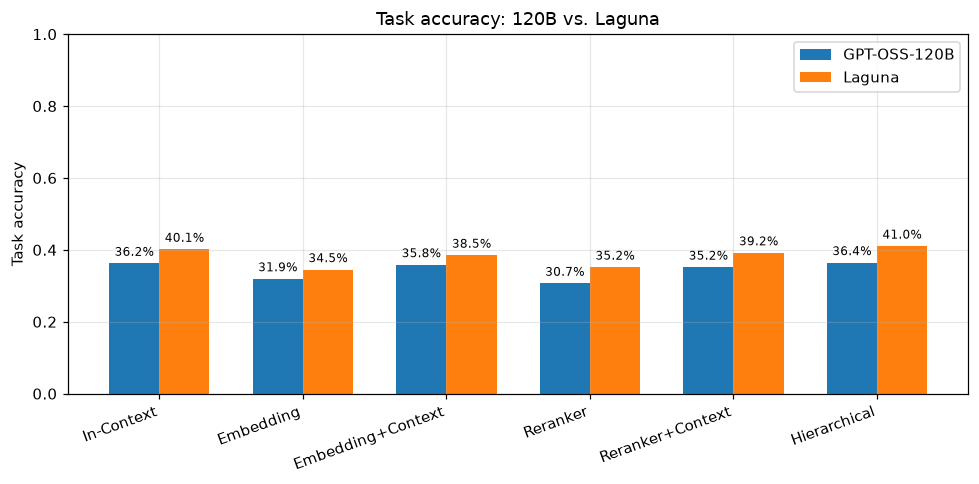

In [35]:
# Task accuracy per strategy, grouped by model
categories = [STRATEGY_LABELS[s] for s in STRATEGIES]
series = {
    m: [all_data[m][s]["metric"]["total_info"]["task"]["accuracy"] for s in STRATEGIES]
    for m in MODELS
}
width = 0.35
x = range(len(categories))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("Task accuracy")
ax.set_ylim(0, max(1.0, max(v for vals in series.values() for v in vals) * 1.15))
ax.set_title("Task accuracy: 120B vs. Laguna")
ax.legend()
plt.tight_layout()
plt.show()


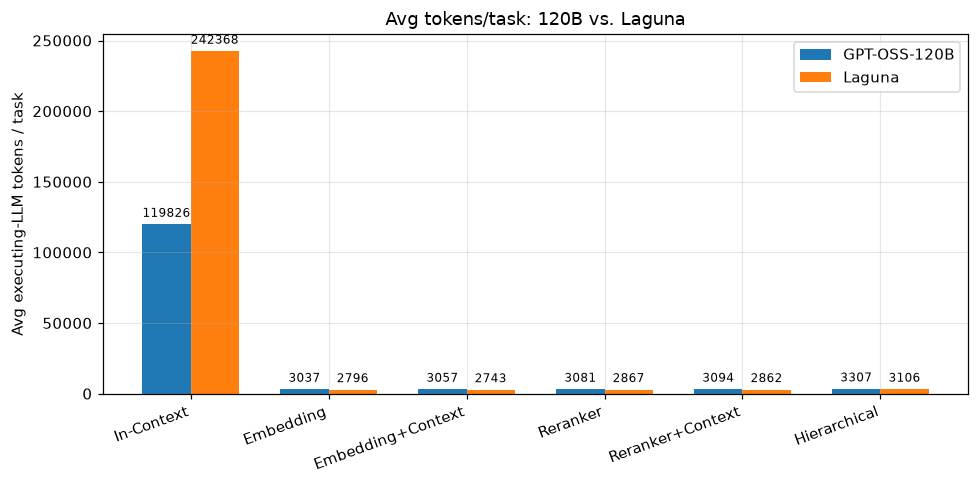

In [36]:
# Avg LLM tokens/task per strategy, grouped by model
series = {m: [token_summary.loc[(m, s), "avg_llm_tokens"] for s in STRATEGIES] for m in MODELS}

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, m in enumerate(MODELS):
    offsets = [xi + i * width - width / 2 for xi in x]
    bars = ax.bar(offsets, series[m], width=width, label=MODEL_LABELS[m])
    ax.bar_label(bars, labels=[f"{v:.0f}" for v in series[m]], padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(categories, rotation=20, ha="right")
ax.set_ylabel("Avg executing-LLM tokens / task")
ax.set_title("Avg tokens/task: 120B vs. Laguna")
ax.legend()
plt.tight_layout()
plt.show()
